<div style="background:linear-gradient(135deg,#4a044e 0%,#a21caf 55%,#e879f9 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#f5d0fe;font-weight:700;text-transform:uppercase">Chapter 150 &middot; Advanced &amp; Applied Topics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">From Model to Production (MLOps) &middot; Challenge Solutions</div>
  <div style="font-size:15px;color:#fae8ff;max-width:740px;line-height:1.6">Worked solutions: package and reload an artifact, register a version, guard the serving endpoint, monitor input drift with PSI across all features, and trigger a retrain that beats the frozen model.</div>
</div>

In [1]:
import numpy as np, pandas as pd, os, json, hashlib, tempfile, joblib
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, recall_score
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.25,"font.size":11})
FU, BL, GR, RD, AM = "#a21caf", "#2563eb", "#16a34a", "#dc2626", "#d97706"
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "from-model-to-production-mlops--delivery-orders.xlsx"
try:
    df = pd.read_excel("../../data/" + fn)
except FileNotFoundError:
    df = pd.read_excel(BASE + fn)
print(df.shape)
print(df.head(3).to_string())

FEATURES = ["distance_km","prep_time_min","courier_load","order_hour","is_weekend","basket_size"]
TARGET = "late"
TMP = tempfile.gettempdir()   # scratch only; nothing here is written to the book repo

def build_pipeline():
    """Preprocessing AND model in one object, so training and serving cannot diverge."""
    pre = ColumnTransformer([("num", StandardScaler(), FEATURES)])
    return Pipeline([("prep", pre), ("clf", LogisticRegression(max_iter=1000))])

(8400, 9)
   order_id  week  distance_km  prep_time_min  courier_load  order_hour  is_weekend  basket_size  late
0         1     1         4.34           15.8             9          12           0        44.36     0
1         2     1         2.68           20.0            11          18           0        35.77     0
2         3     1         4.75           33.0            10          12           0        19.74     1


## Challenge 1 &middot; Package and prove no train/serve skew
Fit a pipeline on weeks 1-6, serialize it, reload it, and show the reloaded artifact scores raw input identically.

In [2]:
pipe = build_pipeline().fit(df[df.week<=6][FEATURES], df[df.week<=6][TARGET])
p = os.path.join(TMP, "sol_model.joblib"); joblib.dump(pipe, p)
served = joblib.load(p)
raw = df[df.week==7][FEATURES]
print("artifact size:", round(os.path.getsize(p)/1024,1), "KB")
print("identical predictions after reload:", np.array_equal(pipe.predict(raw), served.predict(raw)))
print("identical probabilities after reload:", np.allclose(pipe.predict_proba(raw), served.predict_proba(raw)))

artifact size: 2.6 KB
identical predictions after reload: True
identical probabilities after reload: True


## Challenge 2 &middot; Register the model with a content hash
Record name, version, a hash of the exact artifact bytes, the training window, and week-7 metrics as JSON.

In [3]:
from sklearn.metrics import accuracy_score, brier_score_loss
val = df[df.week==7]
proba = served.predict_proba(val[FEATURES])[:,1]
reg = {"name":"late-delivery-classifier","version":"v1",
       "artifact_sha": hashlib.md5(open(p,"rb").read()).hexdigest()[:10],
       "trained_on":"weeks 1-6","features":FEATURES,
       "metrics":{"accuracy":round(accuracy_score(val[TARGET], served.predict(val[FEATURES])),3),
                  "brier":round(brier_score_loss(val[TARGET], proba),3)},
       "status":"production"}
print(json.dumps(reg, indent=2))

{
  "name": "late-delivery-classifier",
  "version": "v1",
  "artifact_sha": "40b22372d9",
  "trained_on": "weeks 1-6",
  "features": [
    "distance_km",
    "prep_time_min",
    "courier_load",
    "order_hour",
    "is_weekend",
    "basket_size"
  ],
  "metrics": {
    "accuracy": 0.727,
    "brier": 0.192
  },
  "status": "production"
}


## Challenge 3 &middot; Harden the serving endpoint
Reject missing columns and out-of-range values, then score valid input and return the probability.

In [4]:
RANGES = {"distance_km":(0,40),"prep_time_min":(0,90),"courier_load":(0,60),
          "order_hour":(0,23),"is_weekend":(0,1),"basket_size":(0,500)}
def serve(order, model):
    miss = [f for f in FEATURES if f not in order]
    if miss: return {"error": f"missing: {miss}"}
    for f,(lo,hi) in RANGES.items():
        if not (lo <= order[f] <= hi): return {"error": f"{f} out of range"}
    x = pd.DataFrame([order])[FEATURES]
    return {"late": int(model.predict_proba(x)[0,1] >= 0.5), "probability": round(float(model.predict_proba(x)[0,1]),3)}
print(serve({"distance_km":12,"prep_time_min":30,"courier_load":18,"order_hour":20,"is_weekend":1,"basket_size":55}, served))
print(serve({"distance_km":12,"prep_time_min":30,"courier_load":18,"order_hour":20,"is_weekend":1}, served))          # missing basket_size
print(serve({"distance_km":12,"prep_time_min":30,"courier_load":999,"order_hour":20,"is_weekend":1,"basket_size":55}, served))  # bad load

{'late': 1, 'probability': 0.984}
{'error': "missing: ['basket_size']"}
{'error': 'courier_load out of range'}


## Challenge 4 &middot; Monitor every feature, not just distance
Compute PSI for all six features at week 10 versus the weeks 1-6 baseline, and rank which drifted most.

courier_load     1.439
distance_km      0.591
basket_size      0.034
prep_time_min    0.020
order_hour       0.004
is_weekend       0.000

drifted (PSI>0.2): ['courier_load', 'distance_km']


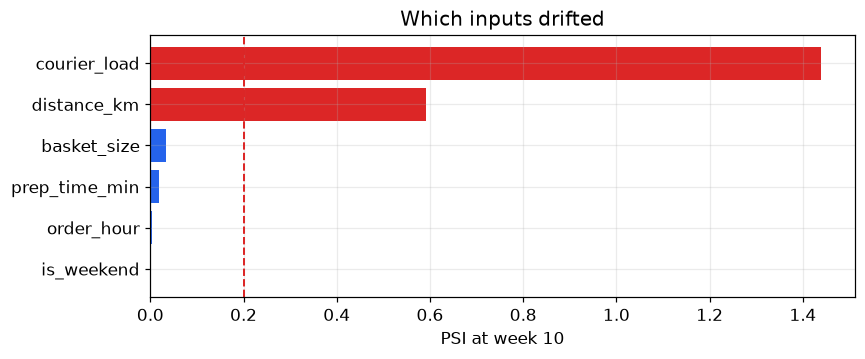

In [5]:
def psi(baseline, current, bins=10):
    e = np.quantile(baseline, np.linspace(0,1,bins+1)); e[0],e[-1]=-np.inf,np.inf
    b = np.clip(np.histogram(baseline,e)[0]/len(baseline),1e-4,None)
    c = np.clip(np.histogram(current,e)[0]/len(current),1e-4,None)
    return float(np.sum((c-b)*np.log(c/b)))
base, wk10 = df[df.week<=6], df[df.week==10]
scores = pd.Series({f: psi(base[f], wk10[f]) for f in FEATURES}).sort_values(ascending=False)
print(scores.round(3).to_string())
print("\ndrifted (PSI>0.2):", list(scores[scores>0.2].index))
fig, ax = plt.subplots(figsize=(8,3.4))
ax.barh(scores.index[::-1], scores.values[::-1], color=[RD if v>0.2 else BL for v in scores.values[::-1]])
ax.axvline(0.2, color=RD, ls="--", lw=1.3); ax.set_xlabel("PSI at week 10"); ax.set_title("Which inputs drifted")
plt.tight_layout(); plt.show()

## Challenge 5 &middot; Trigger a retrain and require it to win
Retrain on weeks 6-9, evaluate champion and challenger on weeks 10-12, and only 'promote' if the challenger improves accuracy.

In [6]:
from sklearn.metrics import accuracy_score, brier_score_loss, recall_score
champion = build_pipeline().fit(df[df.week<=6][FEATURES], df[df.week<=6][TARGET])
challenger = build_pipeline().fit(df[(df.week>=6)&(df.week<=9)][FEATURES], df[(df.week>=6)&(df.week<=9)][TARGET])
test = df[df.week>=10]
def acc(m): return accuracy_score(test[TARGET], m.predict(test[FEATURES]))
ca, ha = acc(champion), acc(challenger)
print(f"champion accuracy (weeks 10-12)   = {ca:.3f}")
print(f"challenger accuracy (weeks 10-12) = {ha:.3f}")
print("decision:", "PROMOTE challenger to v2" if ha > ca else "keep champion")

champion accuracy (weeks 10-12)   = 0.689
challenger accuracy (weeks 10-12) = 0.735
decision: PROMOTE challenger to v2
